# Bloque 2 - NLP: EDA y Preprocesamiento
## Dataset: Resume (Jarvis Calling Hiring Contest)
**Proyecto:** Segmentación de células e interpretación de texto mediante modelos de deep learning  
**Autor:** Dr. Lihki Rubio  


## 0. Importaciones y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

from wordcloud import WordCloud

warnings.filterwarnings('ignore')

# Descargar recursos de NLTK necesarios
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Carga de datos
Se carga el dataset con `pandas` tal como indica el PDF (sección 11.20.6.1.1.1).

In [2]:
DATA_PATH = 'data/Resume.csv'

df = pd.read_csv(DATA_PATH)

print(f'Shape del dataset: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Shape del dataset: (2484, 4)
Columnas: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
# Información general del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [4]:
# Valores nulos
print('=== Valores nulos por columna ===')
print(df.isnull().sum())
print(f'\nTotal de filas duplicadas: {df.duplicated().sum()}')

=== Valores nulos por columna ===
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Total de filas duplicadas: 0


In [5]:
# Identificar columnas de texto y etiqueta
# El dataset Resume tiene columnas: 'ID', 'Resume_str', 'Resume_html', 'Category'
# Ajustar si los nombres difieren
TEXT_COL = 'Resume_str'   # Columna con el texto del resume
LABEL_COL = 'Category'    # Columna con la clase/categoría

# Verificar que las columnas existen
assert TEXT_COL in df.columns, f"Columna '{TEXT_COL}' no encontrada. Columnas: {df.columns.tolist()}"
assert LABEL_COL in df.columns, f"Columna '{LABEL_COL}' no encontrada. Columnas: {df.columns.tolist()}"

print(f'Columna de texto : {TEXT_COL}')
print(f'Columna de clase : {LABEL_COL}')
print(f'Número de clases : {df[LABEL_COL].nunique()}')

Columna de texto : Resume_str
Columna de clase : Category
Número de clases : 24


---
## 2. Análisis de clases
Sección 11.20.6.1.1.2: Conteo de clases con barplot.

In [6]:
class_counts = df[LABEL_COL].value_counts()

print('=== Distribución de clases ===')
print(class_counts)
print(f'\nClase más frecuente : {class_counts.idxmax()} ({class_counts.max()} muestras)')
print(f'Clase menos frecuente: {class_counts.idxmin()} ({class_counts.min()} muestras)')
print(f'Ratio desbalance     : {class_counts.max() / class_counts.min():.2f}x')

=== Distribución de clases ===
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Clase más frecuente : INFORMATION-TECHNOLOGY (120 muestras)
Clase menos frecuente: BPO (22 muestras)
Ratio desbalance     : 5.45x


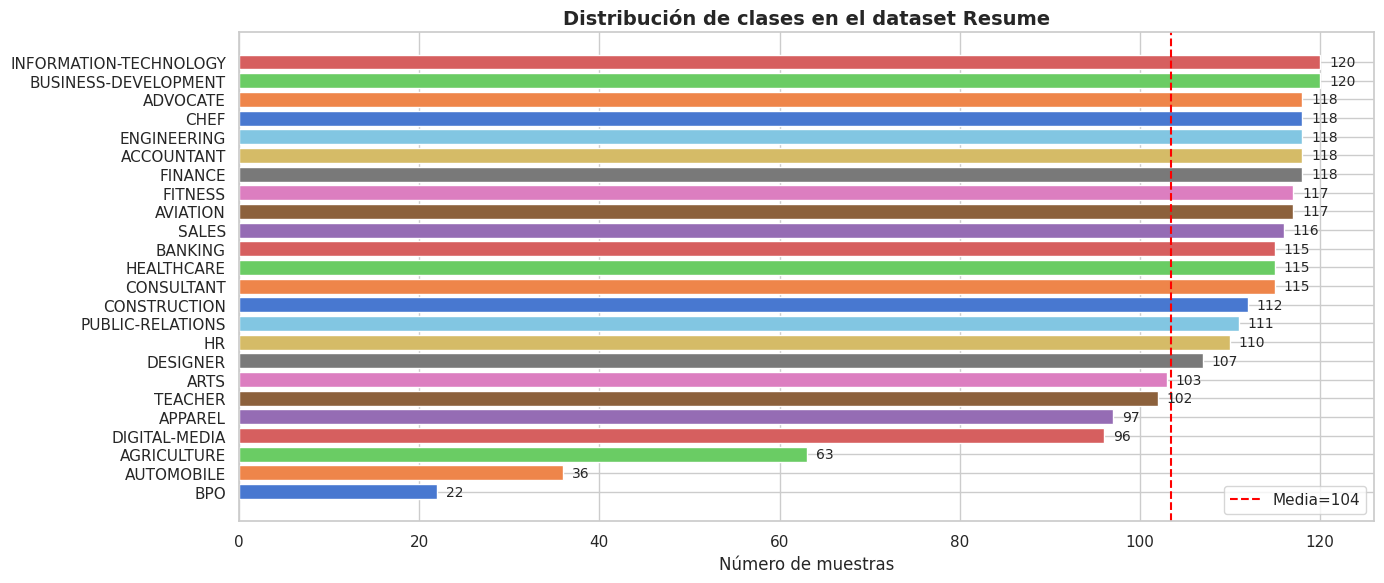

Figura guardada: eda_class_distribution.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(
    class_counts.index[::-1],
    class_counts.values[::-1],
    color=sns.color_palette('muted', len(class_counts))
)

# Etiquetas en cada barra
for bar, val in zip(bars, class_counts.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

ax.set_xlabel('Número de muestras')
ax.set_title('Distribución de clases en el dataset Resume', fontsize=14, fontweight='bold')
ax.axvline(class_counts.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media={class_counts.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150)
plt.show()
print('Figura guardada: eda_class_distribution.png')

---
## 3. Longitud de textos
Sección 11.20.6.1.1.3: Número de palabras por texto → Histograma + Boxplot.

In [8]:
# Calcular número de palabras por texto (sin preprocesar, texto crudo)
df['word_count'] = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))
df['char_count'] = df[TEXT_COL].astype(str).apply(len)

print('=== Estadísticas de longitud de textos (palabras) ===')
print(df['word_count'].describe().round(2))

=== Estadísticas de longitud de textos (palabras) ===
count    2484.00
mean      811.33
std       371.01
min         0.00
25%       651.00
50%       757.00
75%       933.00
max      5190.00
Name: word_count, dtype: float64


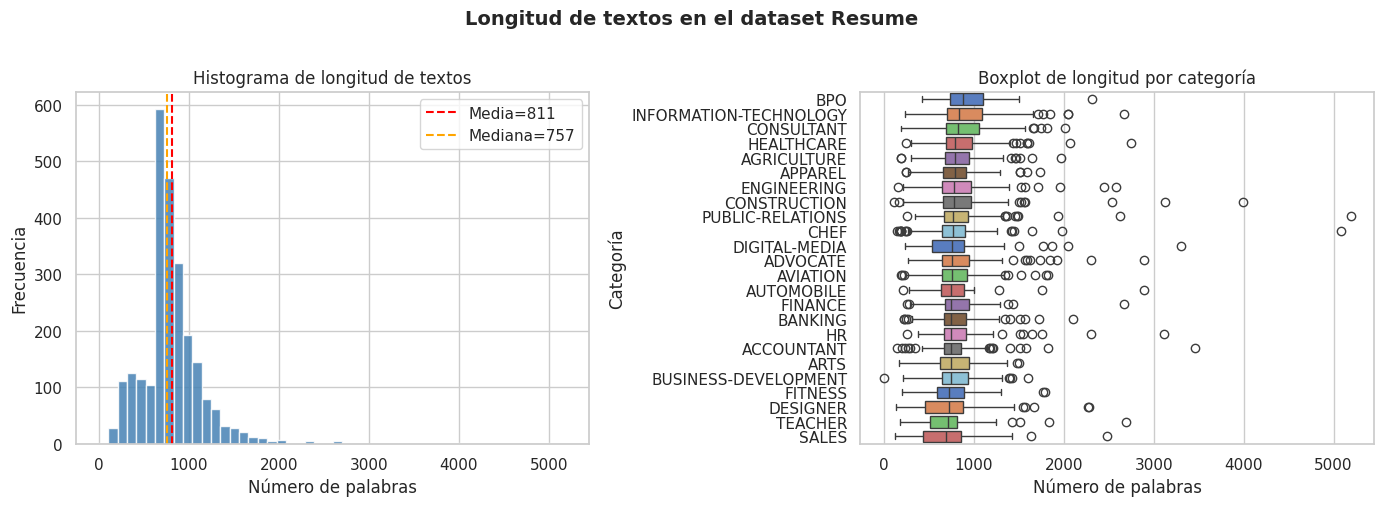

Figura guardada: eda_text_length.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['word_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--',
                label=f'Media={df["word_count"].mean():.0f}')
axes[0].axvline(df['word_count'].median(), color='orange', linestyle='--',
                label=f'Mediana={df["word_count"].median():.0f}')
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Histograma de longitud de textos')
axes[0].legend()

# Boxplot por clase
class_order = df.groupby(LABEL_COL)['word_count'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='word_count', y=LABEL_COL, order=class_order,
            palette='muted', ax=axes[1])
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Categoría')
axes[1].set_title('Boxplot de longitud por categoría')

plt.suptitle('Longitud de textos en el dataset Resume', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: eda_text_length.png')

---
## 4. Frecuencia de palabras
Sección 11.20.6.1.1.4: Top palabras → Barplot top 20 + WordCloud.

In [10]:
STOPWORDS_EN = set(stopwords.words('english'))

def tokenize_simple(text: str) -> list[str]:
    """Tokenización simple: minúsculas + solo alfanumérico + sin stopwords."""
    text = text.lower()
    tokens = re.findall(r'\b[a-z]{3,}\b', text)  # palabras de al menos 3 letras
    tokens = [t for t in tokens if t not in STOPWORDS_EN]
    return tokens

all_tokens = []
for text in df[TEXT_COL].astype(str):
    all_tokens.extend(tokenize_simple(text))

word_freq = Counter(all_tokens)
top20 = word_freq.most_common(20)

print(f'Vocabulario total (sin stopwords): {len(word_freq):,} tokens únicos')
print('\nTop 20 palabras:')
for word, count in top20:
    print(f'  {word:<20} {count:>6}')

Vocabulario total (sin stopwords): 36,895 tokens únicos

Top 20 palabras:
  state                 16159
  company               15212
  city                  15077
  management            12173
  name                  11739
  sales                  8275
  customer               7927
  business               7866
  skills                 7729
  new                    6407
  service                6223
  team                   6073
  development            5731
  training               5637
  experience             5631
  project                5362
  work                   4817
  manager                4534
  information            4502
  marketing              4489


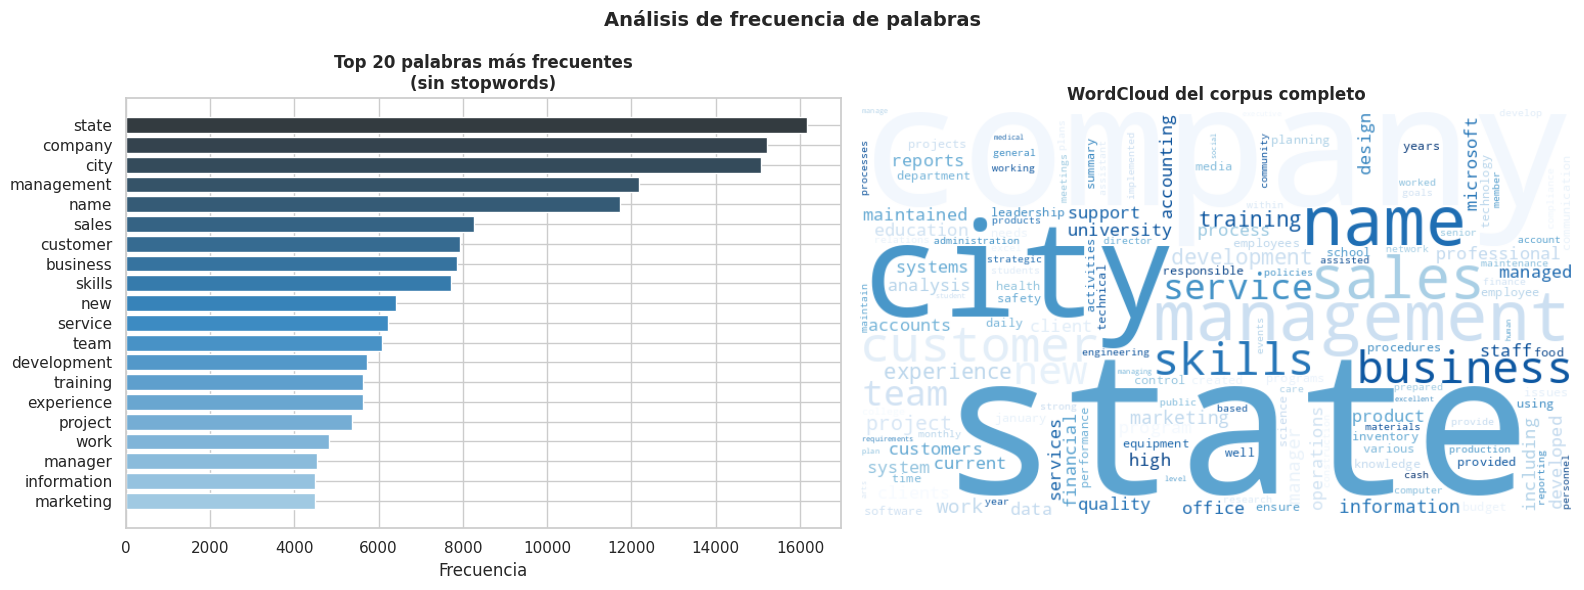

Figura guardada: eda_word_frequency.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot top 20
words_top20, counts_top20 = zip(*top20)
axes[0].barh(words_top20[::-1], counts_top20[::-1],
             color=sns.color_palette('Blues_d', 20))
axes[0].set_xlabel('Frecuencia')
axes[0].set_title('Top 20 palabras más frecuentes\n(sin stopwords)', fontweight='bold')

# WordCloud
wc = WordCloud(
    width=700, height=400,
    background_color='white',
    max_words=150,
    colormap='Blues',
    random_state=RANDOM_SEED
).generate_from_frequencies(word_freq)

axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('WordCloud del corpus completo', fontweight='bold')

plt.suptitle('Análisis de frecuencia de palabras', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: eda_word_frequency.png')

---
## 5. N-gramas
Sección 11.20.6.1.1.5: Bigramas y trigramas más frecuentes.

In [12]:
def get_ngrams(token_list: list[str], n: int) -> Counter:
    """Genera n-gramas y retorna su frecuencia."""
    ngram_list = list(ngrams(token_list, n))
    return Counter([' '.join(g) for g in ngram_list])

bigram_freq   = get_ngrams(all_tokens, 2)
trigram_freq  = get_ngrams(all_tokens, 3)

top15_bi  = bigram_freq.most_common(15)
top15_tri = trigram_freq.most_common(15)

print('=== Top 15 Bigramas ===')
for ng, cnt in top15_bi:
    print(f'  {ng:<35} {cnt:>5}')

print('\n=== Top 15 Trigramas ===')
for ng, cnt in top15_tri:
    print(f'  {ng:<45} {cnt:>5}')

=== Top 15 Bigramas ===
  city state                          14107
  company name                        11563
  name city                            9900
  customer service                     3061
  project management                   1198
  current company                      1177
  microsoft office                     1147
  university city                      1107
  high school                          1069
  business development                  914
  communication skills                  842
  human resources                       819
  public relations                      783
  social media                          760
  problem solving                       759

=== Top 15 Trigramas ===
  company name city                              9900
  name city state                                9719
  current company name                           1173
  university city state                          1030
  manager company name                            704
  january company na

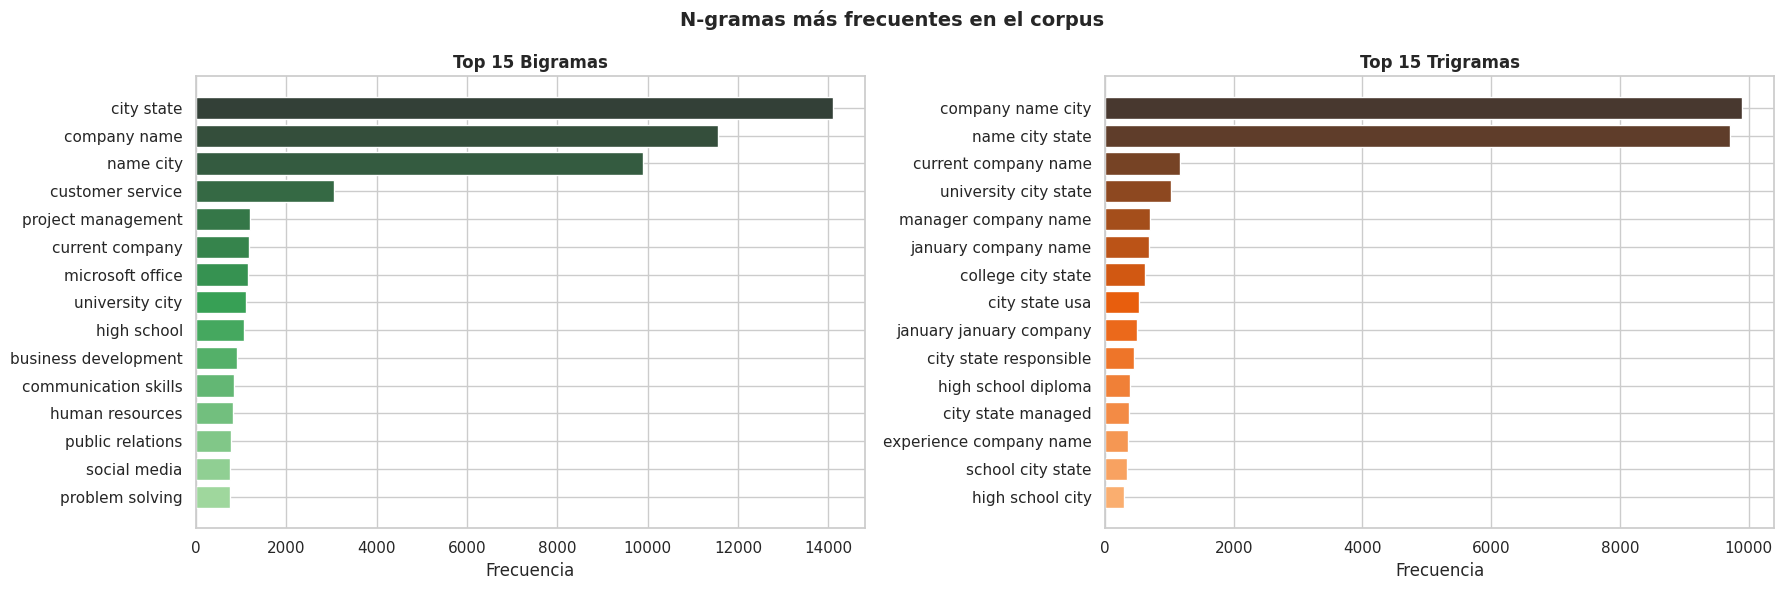

Figura guardada: eda_ngrams.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

def plot_ngrams(ax, top_ngrams, title, palette='Greens_d'):
    phrases, counts = zip(*top_ngrams)
    ax.barh(phrases[::-1], counts[::-1], color=sns.color_palette(palette, len(phrases)))
    ax.set_xlabel('Frecuencia')
    ax.set_title(title, fontweight='bold')

plot_ngrams(axes[0], top15_bi,  'Top 15 Bigramas',  palette='Greens_d')
plot_ngrams(axes[1], top15_tri, 'Top 15 Trigramas', palette='Oranges_d')

plt.suptitle('N-gramas más frecuentes en el corpus', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_ngrams.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: eda_ngrams.png')

---
## 6. Análisis de ruido y calidad de texto

In [14]:
# Detectar posibles fuentes de ruido
df['has_url']        = df[TEXT_COL].astype(str).str.contains(r'http[s]?://', regex=True)
df['has_email']      = df[TEXT_COL].astype(str).str.contains(r'\S+@\S+', regex=True)
df['has_numbers']    = df[TEXT_COL].astype(str).str.contains(r'\d+', regex=True)
df['has_special']    = df[TEXT_COL].astype(str).str.contains(r'[^\w\s]', regex=True)

noise_summary = pd.DataFrame({
    'Tipo de ruido'    : ['URLs', 'Emails', 'Números', 'Caracteres especiales'],
    'Textos afectados' : [
        df['has_url'].sum(),
        df['has_email'].sum(),
        df['has_numbers'].sum(),
        df['has_special'].sum()
    ]
})
noise_summary['Porcentaje (%)'] = (noise_summary['Textos afectados'] / len(df) * 100).round(2)
print(noise_summary.to_string(index=False))

        Tipo de ruido  Textos afectados  Porcentaje (%)
                 URLs                58            2.33
               Emails                25            1.01
              Números              2483           99.96
Caracteres especiales              2483           99.96


---
## 7. Interpretación del EDA
Sección 11.20.6.1.2

In [15]:
# Resumen cuantitativo para guiar la interpretación
balance_ratio = class_counts.max() / class_counts.min()
mean_words    = df['word_count'].mean()
std_words     = df['word_count'].std()
cv_words      = std_words / mean_words  # coeficiente de variación

print('======================================================')
print('         RESUMEN INTERPRETATIVO DEL EDA')
print('======================================================')
print(f'\n1. Balance de clases')
print(f'   Ratio max/min           : {balance_ratio:.2f}x')
print(f'   ¿Clases balanceadas?    : {"SÍ" if balance_ratio < 1.5 else "NO - hay desbalance"}')

print(f'\n2. Longitud de textos')
print(f'   Media palabras          : {mean_words:.0f}')
print(f'   Desviación estándar     : {std_words:.0f}')
print(f'   Coef. de variación      : {cv_words:.2f}')
print(f'   ¿Textos cortos o largos?: {"LARGOS" if mean_words > 200 else "CORTOS"}')
print(f'   ¿Alta variabilidad?     : {"SÍ" if cv_words > 0.5 else "NO"}')

print(f'\n3. Ruido en los textos')
pct_url   = df['has_url'].mean() * 100
pct_email = df['has_email'].mean() * 100
pct_spec  = df['has_special'].mean() * 100
print(f'   Textos con URLs         : {pct_url:.1f}%')
print(f'   Textos con emails       : {pct_email:.1f}%')
print(f'   Textos con simbolos     : {pct_spec:.1f}%')
print(f'   ¿Hay ruido notable?     : {"SÍ" if (pct_url + pct_email) > 10 else "MODERADO"}')
print('======================================================')

         RESUMEN INTERPRETATIVO DEL EDA

1. Balance de clases
   Ratio max/min           : 5.45x
   ¿Clases balanceadas?    : NO - hay desbalance

2. Longitud de textos
   Media palabras          : 811
   Desviación estándar     : 371
   Coef. de variación      : 0.46
   ¿Textos cortos o largos?: LARGOS
   ¿Alta variabilidad?     : NO

3. Ruido en los textos
   Textos con URLs         : 2.3%
   Textos con emails       : 1.0%
   Textos con simbolos     : 100.0%
   ¿Hay ruido notable?     : MODERADO


---
## 8. Preprocesamiento
Sección 11.20.6.2: Pasos obligatorios según el PDF.
1. Minúsculas
2. Eliminación de símbolos
3. Eliminación de stopwords
4. Tokenización
5. Padding (se aplica después con Keras)

In [16]:
def preprocess_text(text: str, stopwords_set: set = STOPWORDS_EN) -> str:
    """
    Pipeline de preprocesamiento de texto (Sección 11.20.6.2):
      1. Conversión a minúsculas
      2. Eliminación de URLs y emails
      3. Eliminación de caracteres no alfabéticos
      4. Eliminación de stopwords
    """
    # 1. Minúsculas
    text = str(text).lower()

    # 2. Eliminar URLs y emails (ruido)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    # 3. Eliminar símbolos / caracteres especiales (solo letras y espacios)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 4. Tokenización y eliminación de stopwords
    tokens = [t for t in text.split() if t not in stopwords_set and len(t) > 2]

    return ' '.join(tokens)


# Aplicar preprocesamiento
print('Aplicando preprocesamiento...')
df['clean_text'] = df[TEXT_COL].apply(preprocess_text)
print('✓ Preprocesamiento completado.')

# Actualizar word_count con texto limpio
df['word_count_clean'] = df['clean_text'].apply(lambda x: len(x.split()))

print(f'\nLongitud media ANTES : {df["word_count"].mean():.0f} palabras')
print(f'Longitud media DESPUÉS: {df["word_count_clean"].mean():.0f} palabras')
print(f'Reducción            : {(1 - df["word_count_clean"].mean()/df["word_count"].mean())*100:.1f}%')

Aplicando preprocesamiento...
✓ Preprocesamiento completado.

Longitud media ANTES : 811 palabras
Longitud media DESPUÉS: 584 palabras
Reducción            : 28.0%


In [17]:
# Comparación visual: texto original vs texto limpio
sample_idx = df.sample(1, random_state=RANDOM_SEED).index[0]

print('=== EJEMPLO DE PREPROCESAMIENTO ===')
print('\n--- TEXTO ORIGINAL (primeros 500 chars) ---')
print(df.loc[sample_idx, TEXT_COL][:500])
print('\n--- TEXTO LIMPIO (primeros 500 chars) ---')
print(df.loc[sample_idx, 'clean_text'][:500])
print(f'\nClase: {df.loc[sample_idx, LABEL_COL]}')

=== EJEMPLO DE PREPROCESAMIENTO ===

--- TEXTO ORIGINAL (primeros 500 chars) ---
           Kpandipou    Koffi         Summary      Compassionate teaching professional delivering exemplary support and assistance to teachers and students. Display exceptional Communication and problem solving skills.  Experience in office administration and public speaking. Attentive and adaptable, skilled in management of classroom operations. Effective in leveraging student feedback to create dynamic lesson plans that address individual strengths and weaknesses.  Dedicated and responsive tea

--- TEXTO LIMPIO (primeros 500 chars) ---
kpandipou koffi summary compassionate teaching professional delivering exemplary support assistance teachers students display exceptional communication problem solving skills experience office administration public speaking attentive adaptable skilled management classroom operations effective leveraging student feedback create dynamic lesson plans address individual streng

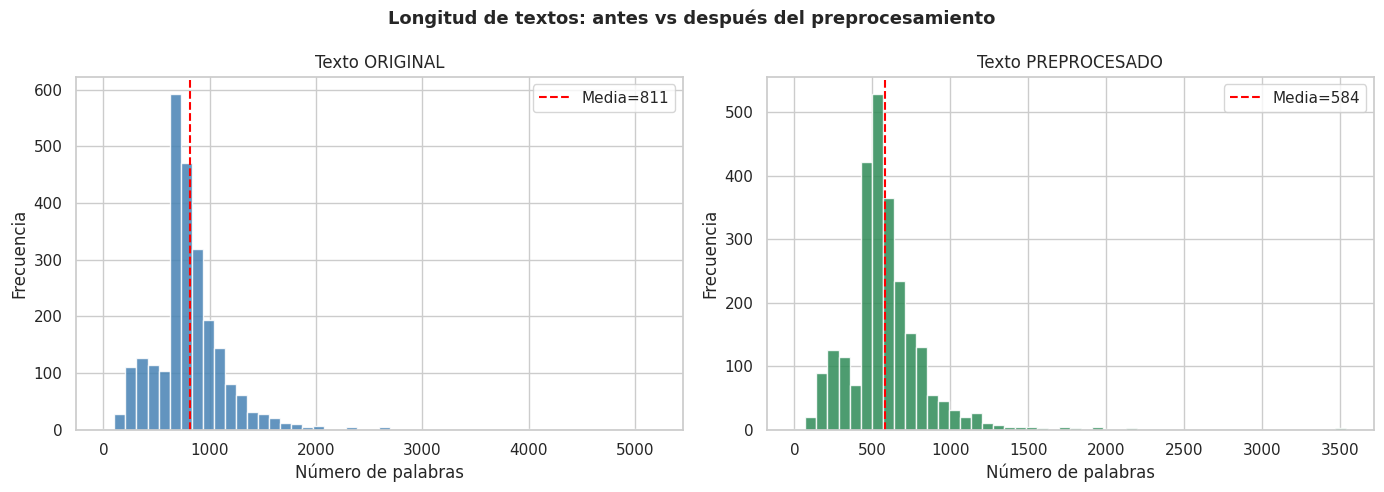

Figura guardada: eda_preprocessing_comparison.png


In [18]:
# Comparación de longitudes: antes vs después
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, color in zip(
    axes,
    ['word_count', 'word_count_clean'],
    ['Texto ORIGINAL', 'Texto PREPROCESADO'],
    ['steelblue', 'seagreen']
):
    ax.hist(df[col], bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--',
               label=f'Media={df[col].mean():.0f}')
    ax.set_xlabel('Número de palabras')
    ax.set_ylabel('Frecuencia')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Longitud de textos: antes vs después del preprocesamiento',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: eda_preprocessing_comparison.png')

---
## 9. Tokenización con Keras y Padding
Sección 11.20.6.2 paso 4-5. Se determina `maxlen` basado en el EDA.

In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(f'TensorFlow version: {tf.__version__}')

# Determinar maxlen según EDA (percentil 95 del texto limpio)
MAX_LEN_P95 = int(np.percentile(df['word_count_clean'], 95))
# El PDF sugiere sequence_length: 50 o 100 según EDA
MAX_LEN = 100 if MAX_LEN_P95 > 75 else 50

print(f'Percentil 95 de longitud limpia : {MAX_LEN_P95} palabras')
print(f'MAX_LEN seleccionado (EDA-based) : {MAX_LEN}')

VOCAB_SIZE = 20000  # límite de vocabulario

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])

vocab_actual = len(tokenizer.word_index)
print(f'\nVocabulario total encontrado : {vocab_actual:,} tokens')
print(f'Vocabulario limitado a       : {VOCAB_SIZE:,} tokens')
print(f'Cobertura aproximada         : {min(VOCAB_SIZE/vocab_actual*100, 100):.1f}%')

2026-04-29 18:38:38.315953: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 18:38:39.269360: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-29 18:38:41.950610: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
Percentil 95 de longitud limpia : 1008 palabras
MAX_LEN seleccionado (EDA-based) : 100

Vocabulario total encontrado : 36,949 tokens
Vocabulario limitado a       : 20,000 tokens
Cobertura aproximada         : 54.1%


In [20]:
# Convertir textos a secuencias y aplicar padding
sequences = tokenizer.texts_to_sequences(df['clean_text'])
X_padded  = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Shape del array de secuencias padded: {X_padded.shape}')
print(f'  → {X_padded.shape[0]} muestras × {X_padded.shape[1]} tokens por secuencia')

# Codificación de etiquetas
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(df[LABEL_COL])

print(f'\nClases codificadas ({len(le.classes_)}): {list(le.classes_)}')

Shape del array de secuencias padded: (2484, 100)
  → 2484 muestras × 100 tokens por secuencia

Clases codificadas (24): ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


In [21]:
# Split Train / Validation / Test  (70 / 15 / 15)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_padded, y_encoded, test_size=0.30,
    random_state=RANDOM_SEED, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=RANDOM_SEED, stratify=y_temp
)

print('=== Tamaños de splits ===')
print(f'  Train      : {X_train.shape[0]:>5} muestras  ({X_train.shape[0]/len(X_padded)*100:.1f}%)')
print(f'  Validation : {X_val.shape[0]:>5} muestras  ({X_val.shape[0]/len(X_padded)*100:.1f}%)')
print(f'  Test       : {X_test.shape[0]:>5} muestras  ({X_test.shape[0]/len(X_padded)*100:.1f}%)')

=== Tamaños de splits ===
  Train      :  1738 muestras  (70.0%)
  Validation :   373 muestras  (15.0%)
  Test       :   373 muestras  (15.0%)


---
## 10. Guardar artefactos del preprocesamiento

In [22]:
import pickle, os

os.makedirs('artifacts', exist_ok=True)

# Guardar tokenizador
with open('artifacts/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Guardar label encoder
with open('artifacts/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Guardar arrays numpy
np.save('artifacts/X_train.npy', X_train)
np.save('artifacts/X_val.npy',   X_val)
np.save('artifacts/X_test.npy',  X_test)
np.save('artifacts/y_train.npy', y_train)
np.save('artifacts/y_val.npy',   y_val)
np.save('artifacts/y_test.npy',  y_test)

# Guardar configuración
config = {
    'MAX_LEN'   : MAX_LEN,
    'VOCAB_SIZE' : VOCAB_SIZE,
    'NUM_CLASSES': len(le.classes_),
    'CLASSES'   : list(le.classes_),
    'TEXT_COL'  : TEXT_COL,
    'LABEL_COL' : LABEL_COL,
}
with open('artifacts/config.pkl', 'wb') as f:
    pickle.dump(config, f)

print('✓ Artefactos guardados en artifacts/')
print('  - tokenizer.pkl')
print('  - label_encoder.pkl')
print('  - X_train/val/test.npy')
print('  - y_train/val/test.npy')
print('  - config.pkl')
print(f'\nConfiguración del pipeline:')
for k, v in config.items():
    if k != 'CLASSES':
        print(f'  {k:<15}: {v}')

✓ Artefactos guardados en artifacts/
  - tokenizer.pkl
  - label_encoder.pkl
  - X_train/val/test.npy
  - y_train/val/test.npy
  - config.pkl

Configuración del pipeline:
  MAX_LEN        : 100
  VOCAB_SIZE     : 20000
  NUM_CLASSES    : 24
  TEXT_COL       : Resume_str
  LABEL_COL      : Category


---
## Resumen final

| Paso | Estado |
|---|---|
| Carga de datos (pandas) | ✅ |
| Análisis de clases (barplot) | ✅ |
| Longitud de textos (histograma + boxplot) | ✅ |
| Frecuencia de palabras (barplot + WordCloud) | ✅ |
| N-gramas (bigramas y trigramas) | ✅ |
| Análisis de ruido | ✅ |
| Preprocesamiento (minúsculas + símbolos + stopwords) | ✅ |
| Tokenización (Keras) | ✅ |
| Padding (Keras) | ✅ |
| Split Train/Val/Test 70/15/15 | ✅ |
| Guardado de artefactos | ✅ |

**Siguientes pasos:** Notebook `02_Embeddings_Modelos.ipynb` → Word2Vec, FastText, y los 5 modelos NLP.